In [3]:
!pip install fastapi uvicorn python-multipart google-genai gradio pydantic scikit-learn seaborn -q
print("All packages installed")

All packages installed


In [4]:
import os
os.makedirs("skin-disease-advisor/app", exist_ok=True)
os.makedirs("skin-disease-advisor/train", exist_ok=True)
os.makedirs("skin-disease-advisor/ui", exist_ok=True)
os.makedirs("skin-disease-advisor/models", exist_ok=True)
print("Folders created")

Folders created


In [5]:
%%writefile /kaggle/working/skin-disease-advisor/app/schemas.py
from pydantic import BaseModel
from typing import List

class PredictionItem(BaseModel):
    disease: str
    confidence: float

class SkinAnalysisResponse(BaseModel):
    disease: str
    confidence: float
    top_predictions: List[PredictionItem]
    recommendations: List[str]
    next_steps: List[str]
    tips: List[str]

class HealthResponse(BaseModel):
    status: str
    model_loaded: bool

Overwriting /kaggle/working/skin-disease-advisor/app/schemas.py


In [6]:
%%writefile /kaggle/working/skin-disease-advisor/app/utils.py
import torch
from torchvision import transforms
from PIL import Image

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def get_transforms(train=False, imgsz=300):
    if train:
        return transforms.Compose([
            transforms.Resize((int(imgsz * 1.07), int(imgsz * 1.07))),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.5),         
            transforms.RandomRotation(180),                 
            transforms.ColorJitter(
                brightness=0.2, contrast=0.2,
                saturation=0.1,                             
                hue=0.0                                  
            ),
            transforms.RandomResizedCrop(imgsz, scale=(0.8, 1.0)),  
            transforms.RandomAffine(
                degrees=0,                                 
                translate=(0.1, 0.1),                      
                scale=(0.9, 1.1)                           
            ),
            transforms.RandomPerspective(distortion_scale=0.2, p=0.3),  
            transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),   
            transforms.RandomAutocontrast(p=0.3),
            transforms.RandomEqualize(p=0.2),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])
    return transforms.Compose([
        transforms.Resize((imgsz, imgsz)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

def preprocess_image(image: Image.Image) -> torch.Tensor:
    return get_transforms(False, 300)(image.convert("RGB")).unsqueeze(0)

Overwriting /kaggle/working/skin-disease-advisor/app/utils.py


In [7]:
%%writefile /kaggle/working/skin-disease-advisor/app/model.py
import torch
import torch.nn as nn
from torchvision import models
from PIL import Image
from typing import Tuple, List
from app.utils import preprocess_image
from app.schemas import PredictionItem

DISEASE_CLASSES = [
    "Eczema",
    "Warts, Molluscum & Viral Infections",
    "Melanoma",
    "Atopic Dermatitis",
    "Basal Cell Carcinoma (BCC)",
    "Melanocytic Nevi (NV)",
    "Benign Keratosis-like Lesions (BKL)",
    "Psoriasis & Lichen Planus",
    "Seborrheic Keratoses & Benign Tumors",
    "Tinea, Ringworm & Fungal Infections",
]

NUM_CLASSES = len(DISEASE_CLASSES)


def build_model(num_classes=NUM_CLASSES, freeze_backbone=False):
    model = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1)
    if freeze_backbone:
        for p in model.features.parameters(): p.requires_grad = False
    in_f = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.3), nn.Linear(in_f, num_classes),
        
    )
    return model

class SkinDiseaseClassifier:
    def __init__(self):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = None
        self.is_loaded = False

    def load_model(self, path):
        self.model = build_model(NUM_CLASSES)
        try:
            self.model.load_state_dict(torch.load(path, map_location=self.device))
            print(f"Loaded weights from {path}")
        except FileNotFoundError:
            print(f"WARNING: {path} not found — using ImageNet backbone.")
        self.model.to(self.device).eval()
        self.is_loaded = True

    @torch.no_grad()
    def predict(self, image: Image.Image) -> Tuple[str, float, List[PredictionItem]]:
        tensor = preprocess_image(image).to(self.device)
        probs = torch.softmax(self.model(tensor), dim=1)[0]
        top5_vals, top5_idx = torch.topk(probs, 5)
        return (
            DISEASE_CLASSES[top5_idx[0].item()],
            top5_vals[0].item(),
            [PredictionItem(disease=DISEASE_CLASSES[i.item()], confidence=round(v.item(),4))
             for v, i in zip(top5_vals, top5_idx)]
        )


Overwriting /kaggle/working/skin-disease-advisor/app/model.py


In [8]:
%%writefile /kaggle/working/skin-disease-advisor/app/llm.py
import os, json, re
from typing import Dict, List

GEMINI_API_KEY = os.getenv("GEMINI_API_KEY", "")

SYSTEM_PROMPT = """You are a professional dermatologist AI assistant.
Respond ONLY with a valid JSON object — no extra text:

{
  "recommendations": ["...", "...", "..."],
  "next_steps": ["...", "...", "..."],
  "tips": ["...", "...", "..."]
}

3-5 items each. Be concise and medically accurate.
Always recommend consulting a licensed dermatologist."""


def _fallback(disease: str) -> Dict[str, List[str]]:
    return {
        "recommendations": [
            f"AI detected {disease} — preliminary screening only.",
            "Do not self-medicate based on this result.",
            "Consult a licensed dermatologist for accurate diagnosis.",
        ],
        "next_steps": [
            "Book an appointment with a dermatologist.",
            "Avoid scratching or picking the affected area.",
            "Photograph the area to show your doctor.",
        ],
        "tips": [
            "Keep the area clean and moisturized.",
            "Avoid harsh soaps and skin irritants.",
            "Wear loose breathable clothing.",
            "Stay hydrated and maintain a balanced diet.",
        ],
    }


def get_llm_recommendations(disease: str, confidence: float) -> Dict[str, List[str]]:
    if not GEMINI_API_KEY:
        return _fallback(disease)
    try:
        from google import genai                              
        client = genai.Client(api_key=GEMINI_API_KEY)
        resp = client.models.generate_content(
            model="gemini-2.5-flash",
            contents=f"Detected condition: {disease}\nConfidence: {confidence*100:.1f}%\nProvide recommendations.",
            config=genai.types.GenerateContentConfig(
                system_instruction=SYSTEM_PROMPT
            )
        )
        raw = resp.text.strip()
        match = re.search(r"```(?:json)?(.*?)```", raw, re.DOTALL)
        return json.loads(match.group(1).strip() if match else raw)
    except Exception as e:
        print(f"[LLM ERROR] {e}")
        return _fallback(disease)

Overwriting /kaggle/working/skin-disease-advisor/app/llm.py


In [16]:
%%writefile /kaggle/working/skin-disease-advisor/app/main.py
import io
import gradio as gr
from fastapi import FastAPI, File, UploadFile, HTTPException
from fastapi.middleware.cors import CORSMiddleware
from PIL import Image
from app.model import SkinDiseaseClassifier
from app.llm import get_llm_recommendations
from app.schemas import SkinAnalysisResponse, HealthResponse
   

app = FastAPI(
    title="Skin Disease Detection & LLM Advisor",
    version="1.0.0",
    description="EfficientNet-B3 skin disease classifier with Gemini LLM recommendations"
)

app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"], allow_methods=["*"], allow_headers=["*"]
)

classifier = SkinDiseaseClassifier()

@app.on_event("startup")
async def startup():
    classifier.load_model("models/efficientnet_skin.pth")

@app.get("/health", response_model=HealthResponse, tags=["System"])
def health():
    return HealthResponse(status="healthy", model_loaded=classifier.is_loaded)

@app.post("/analyze-skin", response_model=SkinAnalysisResponse, tags=["Prediction"])
async def analyze_skin(file: UploadFile = File(...)):
    if not file.content_type.startswith("image/"):
        raise HTTPException(400, "File must be an image.")
    contents = await file.read()
    try:
        image = Image.open(io.BytesIO(contents)).convert("RGB")
    except Exception:
        raise HTTPException(422, "Cannot decode image.")
    disease, confidence, top5 = classifier.predict(image)
    recs = get_llm_recommendations(disease, confidence)
    return SkinAnalysisResponse(
        disease=disease,
        confidence=round(confidence, 4),
        top_predictions=top5,
        recommendations=recs["recommendations"],
        next_steps=recs["next_steps"],
        tips=recs["tips"],
    )



Overwriting /kaggle/working/skin-disease-advisor/app/main.py


In [10]:
%%writefile /kaggle/working/skin-disease-advisor/train/train.py
import argparse, os, sys
sys.path.insert(0, os.path.join(os.path.dirname(__file__), ".."))

import torch, torch.nn as nn
import numpy as np
from torch.utils.data import DataLoader, random_split, WeightedRandomSampler, Dataset
from torchvision import datasets
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from app.model import build_model, NUM_CLASSES
from app.utils import get_transforms



class TransformSubset(Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, idx):
        img, label = self.subset[idx]
        return self.transform(img), label

    def __len__(self):
        return len(self.subset)



def train(args):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device: {device}")
    print(f"Epochs: {args.epochs} | ImgSize: {args.imgsz} | Batch: {args.batch} | Patience: {args.patience}")

    # Load WITHOUT any transform — transforms applied per-split below
    full_ds = datasets.ImageFolder(args.data_dir)
    n_val = int(len(full_ds) * 0.15)
    train_split, val_split = random_split(
        full_ds, [len(full_ds) - n_val, n_val],
        generator=torch.Generator().manual_seed(42)
    )

    # Each split gets its own transform — no shared-dataset bug
    train_ds = TransformSubset(train_split, get_transforms(True,  args.imgsz))
    val_ds   = TransformSubset(val_split,   get_transforms(False, args.imgsz))

    # WeightedRandomSampler — uses train_split.indices (still valid)
    targets = [full_ds.targets[i] for i in train_split.indices]
    class_counts = np.bincount(targets)
    weights = 1.0 / class_counts[targets]
    sampler = WeightedRandomSampler(weights, len(weights), replacement=True)

    train_loader = DataLoader(train_ds, batch_size=args.batch, sampler=sampler, num_workers=2)
    val_loader   = DataLoader(val_ds,   batch_size=args.batch, shuffle=False,   num_workers=2)
    print(f"Train: {len(train_ds):,} Val: {len(val_ds):,}")

    cw = torch.FloatTensor(1.0 / class_counts).to(device)
    cw = cw / cw.sum() * NUM_CLASSES
    criterion = nn.CrossEntropyLoss(weight=cw, label_smoothing=0.1)

    model = build_model(NUM_CLASSES, freeze_backbone=True).to(device)
    optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=args.lr, weight_decay=1e-4)
    scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2)

    best_val_acc = 0.0
    epochs_no_improve = 0
    os.makedirs(args.output, exist_ok=True)

    for epoch in range(1, args.epochs + 1):
        if epoch == 10:
            for p in model.features.parameters():
                p.requires_grad = True
            optimizer = AdamW(model.parameters(), lr=args.lr * 0.1, weight_decay=1e-4)
            scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2)
            print("✓ Backbone unfrozen at epoch 10.")

        model.train()
        total_loss, correct, total = 0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            correct += (out.argmax(1) == labels).sum().item()
            total += imgs.size(0)
        scheduler.step()

        model.eval()
        vc, vt = 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                vc += (model(imgs).argmax(1) == labels).sum().item()
                vt += imgs.size(0)
        val_acc = vc / vt
        print(f"Epoch {epoch:03d}/{args.epochs} loss={total_loss/total:.4f} "
              f"train_acc={correct/total:.4f} val_acc={val_acc:.4f}", flush=True)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            epochs_no_improve = 0
            torch.save(model.state_dict(), os.path.join(args.output, "efficientnet_skin.pth"))
            print(f"  ✓ Best model saved! val_acc={val_acc:.4f}")
        else:
            epochs_no_improve += 1
            print(f"  No improvement. Patience: {epochs_no_improve}/{args.patience}")
            if epochs_no_improve >= args.patience:
                print(f"\n⏹ Early stopping at epoch {epoch}.")
                break

    print(f"\n🎉 Done! Best val accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")


if __name__ == "__main__":
    p = argparse.ArgumentParser()
    p.add_argument("--data_dir", default="data")
    p.add_argument("--epochs",   type=int,   default=50)
    p.add_argument("--imgsz",    type=int,   default=300)
    p.add_argument("--batch",    type=int,   default=32)
    p.add_argument("--lr",       type=float, default=1e-3)
    p.add_argument("--patience", type=int,   default=10)
    p.add_argument("--output",   default="models")
    train(p.parse_args())

Overwriting /kaggle/working/skin-disease-advisor/train/train.py


In [25]:
%%writefile /kaggle/working/skin-disease-advisor/ui/gradio_app.py
import gradio as gr
import requests
import json
from PIL import Image
import io
import os

API_URL = os.environ.get("API_URL", "http://localhost:7860")

DISEASE_INFO = {
    "1. Eczema":                                              {"severity": "LOW-MEDIUM",  "color": "ffbb00"},
    "10. Warts Molluscum and other Viral Infections":       {"severity": "LOW",         "color": "00aa44"},
    "2. Melanoma":                                          {"severity": "HIGH",        "color": "ff4444"},
    "3. Atopic Dermatitis":                                {"severity": "LOW-MEDIUM",  "color": "ffbb00"},
    "4. Basal Cell Carcinoma (BCC)":                          {"severity": "MEDIUM-HIGH", "color": "ff8800"},
    "5. Melanocytic Nevi (NV)":                             {"severity": "LOW",         "color": "00aa44"},
    "6. Benign Keratosis-like Lesions (BKL)":                 {"severity": "LOW",         "color": "00aa44"},
    "7. Psoriasis pictures Lichen Planus and related diseases":{"severity": "LOW-MEDIUM", "color": "ffbb00"},
    "8. Seborrheic Keratoses and other Benign Tumors":      {"severity": "LOW",         "color": "00aa44"},
    "9. Tinea Ringworm Candidiasis and other Fungal Infections":{"severity": "LOW-MEDIUM","color": "ffbb00"},
}

SEVERITY_DOT = {
    "LOW":         "00aa44",
    "LOW-MEDIUM":  "ffbb00",
    "MEDIUM-HIGH": "ff8800",
    "HIGH":        "ff4444",
    "UNKNOWN":     "888888",
}


CSS = """
* { box-sizing: border-box; }

.gradio-container {
    max-width: 1100px !important;
    margin: 0 auto !important;
    font-family: 'Segoe UI', sans-serif !important;
}

.app-header {
    background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%);
    border-radius: 16px;
    padding: 32px;
    text-align: center;
    margin-bottom: 24px;
    border: 1px solid #0f3460;
}

.app-header h1 {
    color: #ffffff !important;
    font-size: 2rem !important;
    font-weight: 700 !important;
    margin: 0 0 8px 0 !important;
    letter-spacing: -0.5px;
}

.app-header p {
    color: #94a3b8 !important;
    font-size: 1rem !important;
    margin: 0 !important;
}

.result-card {
    background: #1e293b;
    border-radius: 12px;
    padding: 20px;
    border: 1px solid #334155;
    margin-bottom: 16px;
}

.disease-name {
    font-size: 1.5rem;
    font-weight: 700;
    color: #f1f5f9;
    margin-bottom: 4px;
}

.confidence-text {
    font-size: 1rem;
    color: #94a3b8;
    margin-bottom: 16px;
}

.severity-badge {
    display: inline-block;
    padding: 4px 12px;
    border-radius: 999px;
    font-size: 0.85rem;
    font-weight: 600;
    margin-bottom: 16px;
}

.bar-container {
    margin: 6px 0;
}

.bar-label {
    display: flex;
    justify-content: space-between;
    font-size: 0.85rem;
    color: #cbd5e1;
    margin-bottom: 4px;
}

.bar-track {
    background: #334155;
    border-radius: 999px;
    height: 8px;
    overflow: hidden;
}

.bar-fill {
    height: 100%;
    border-radius: 999px;
    background: linear-gradient(90deg, #3b82f6, #06b6d4);
    transition: width 0.5s ease;
}

.bar-fill-top {
    background: linear-gradient(90deg, #6366f1, #8b5cf6) !important;
}

.info-section {
    background: #1e293b;
    border-radius: 12px;
    padding: 20px;
    border: 1px solid #334155;
    margin-bottom: 12px;
}

.info-section h3 {
    color: #e2e8f0 !important;
    font-size: 0.95rem !important;
    font-weight: 600 !important;
    text-transform: uppercase;
    letter-spacing: 0.05em;
    margin: 0 0 10px 0 !important;
    opacity: 0.7;
}

.info-section p {
    color: #cbd5e1 !important;
    font-size: 0.95rem !important;
    margin: 0 !important;
    line-height: 1.6 !important;
}

.action-box {
    border-radius: 10px;
    padding: 14px 18px;
    font-weight: 600;
    font-size: 0.95rem;
    margin-top: 12px;
}

.disclaimer {
    background: #1e1e2e;
    border: 1px solid #ff444433;
    border-radius: 10px;
    padding: 12px 16px;
    color: #ff8888 !important;
    font-size: 0.82rem !important;
    text-align: center;
    margin-top: 16px;
}

.upload-area {
    border-radius: 12px !important;
    border: 2px dashed #334155 !important;
}

.analyze-btn {
    background: linear-gradient(135deg, #3b82f6, #6366f1) !important;
    border: none !important;
    border-radius: 10px !important;
    font-weight: 700 !important;
    font-size: 1rem !important;
    padding: 14px !important;
    color: white !important;
    cursor: pointer !important;
    width: 100% !important;
    transition: opacity 0.2s !important;
}

.analyze-btn:hover { opacity: 0.9 !important; }

.empty-state {
    text-align: center;
    padding: 48px 24px;
    color: #475569;
    font-size: 0.95rem;
}

.empty-state .icon { font-size: 3rem; margin-bottom: 12px; }
"""

def build_result_html(data):
    disease         = data.get("disease", "Unknown")
    confidence      = data.get("confidence", 0) * 100
    top5            = data.get("top_predictions", [])
    recommendations = data.get("recommendations", ["Consult a licensed dermatologist."])
    next_steps      = data.get("next_steps", ["Book an appointment with a dermatologist."])
    tips            = data.get("tips", ["Keep the area clean and moisturized."])

    # Still use DISEASE_INFO for severity + color ONLY
    info     = DISEASE_INFO.get(disease, {})
    severity = info.get("severity", "UNKNOWN")
    color    = info.get("color", "888888")

    def to_list_html(items):
        if isinstance(items, list):
            return "".join(f"<li style='margin-bottom:6px'>• {i}</li>" for i in items)
        return f"<li>• {items}</li>"

    # Top predictions bars
    bars_html = ""
    for i, p in enumerate(top5):
        pct   = p["confidence"] * 100
        name  = p["disease"]
        extra = "bar-fill-top" if i == 0 else ""
        bars_html += f"""
        <div class="bar-container">
            <div class="bar-label">
                <span>{"👑 " if i == 0 else f"{i+1}. "}{name}</span>
                <span><b>{pct:.1f}%</b></span>
            </div>
            <div class="bar-track">
                <div class="bar-fill {extra}" style="width:{pct:.1f}%"></div>
            </div>
        </div>"""

    html = f"""
    <div class="result-card">
        <div class="disease-name">🔬 {disease}</div>
        <div class="confidence-text">Confidence: <b>{confidence:.1f}%</b></div>
        <div class="severity-badge" style="background:{color}22; color:{color}; border:1px solid {color}55">
            {severity}
        </div>
        <div style="margin-top:16px">
            <div style="font-size:0.8rem;color:#64748b;text-transform:uppercase;letter-spacing:0.05em;margin-bottom:10px;font-weight:600">TOP PREDICTIONS</div>
            {bars_html}
        </div>
    </div>

    <div class="info-section">
        <h3>📖 About</h3>
        <p>{about}</p>
    </div>

    <div class="info-section">
        <h3>🩹 Symptoms</h3>
        <p>{symptoms}</p>
    </div>

    <div class="info-section">
        <h3>✅ Recommended Action</h3>
        <div class="action-box" style="background:{color}22; color:{color}; border:1px solid {color}44">
            {action}
        </div>
    </div>

    <div class="disclaimer">
        ⚠️ This tool is for educational purposes only and is NOT a substitute for professional medical advice.
        Always consult a qualified dermatologist for diagnosis and treatment.
    </div>
    """
    return html

def analyze_image(image):
    if image is None:
        return """<div class="empty-state">
            <div class="icon">🩺</div>
            <div>Upload a skin image and click <b>Analyze</b> to get started</div>
        </div>"""

    buf = io.BytesIO()
    image.save(buf, format="JPEG")
    buf.seek(0)

    try:
        resp = requests.post(
            f"{API_URL}/analyze-skin",
            files={"file": ("image.jpg", buf, "image/jpeg")},
            timeout=30
        )
        data = resp.json()
    except Exception as e:
        return f"""<div class="result-card" style="border-color:#ff4444">
            <div style="color:#ff4444;font-weight:700">❌ Connection Error</div>
            <div style="color:#94a3b8;margin-top:8px">Could not reach the API.<br><code>{e}</code></div>
        </div>"""

    return build_result_html(data)

with gr.Blocks(css=CSS, title="Skin Disease Advisor", theme=gr.themes.Base()) as demo:

    gr.HTML("""
    <div class="app-header">
        <h1>🩺 Skin Disease Advisor</h1>
        <p>AI-powered skin disease detection </p>
    </div>
    """)

    with gr.Row(equal_height=True):
        with gr.Column(scale=1):
            image_input = gr.Image(
                type="pil",
                label="Upload Skin Image",
                elem_classes=["upload-area"],
                height=320
            )
            analyze_btn = gr.Button(
                "🔍 Analyze Image",
                variant="primary",
                elem_classes=["analyze-btn"]
            )
            gr.HTML("""
            <div style="margin-top:12px; padding:12px; background:#1e293b;
                        border-radius:10px; border:1px solid #334155">
                <div style="font-size:0.8rem; color:#64748b; font-weight:600;
                             text-transform:uppercase; letter-spacing:0.05em; margin-bottom:8px">
                    Detects These Conditions
                </div>
                <div style="font-size:0.82rem; color:#94a3b8; line-height:1.8">
                    🔴 Melanoma &nbsp;|&nbsp; 🔴 Basal Cell Carcinoma<br>
                    🟡 Eczema &nbsp;|&nbsp; 🟡 Atopic Dermatitis<br>
                    🟡 Psoriasis &nbsp;|&nbsp; 🟡 Tinea Ringworm<br>
                    🟢 Melanocytic Nevi &nbsp;|&nbsp; 🟢 Warts<br>
                    🟢 Seborrheic Keratoses &nbsp;|&nbsp; 🟢 Benign Lesions
                </div>
            </div>
            """)

        with gr.Column(scale=1):
            result_html = gr.HTML("""
            <div class="empty-state">
                <div class="icon">🩺</div>
                <div>Upload a skin image and click <b>Analyze</b> to get started</div>
            </div>
            """)

    analyze_btn.click(
        fn=analyze_image,
        inputs=image_input,
        outputs=result_html
    )

if __name__ == "__main__":
    demo.launch(server_name="0.0.0.0", server_port=7860, share=False)

Overwriting /kaggle/working/skin-disease-advisor/ui/gradio_app.py


In [13]:
import subprocess, sys

BASE = "/kaggle/working/skin-disease-advisor"

process = subprocess.Popen(
    [sys.executable, "train/train.py",
     "--data_dir", "/kaggle/input/datasets/ismailpromus/skin-diseases-image-dataset/IMG_CLASSES",
     "--epochs",   "50",
     "--imgsz",    "300",
     "--batch",    "16",
     "--lr",       "0.001",
     "--patience", "10",
     "--output",   f"{BASE}/models/"],
    cwd=BASE,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1
)


for line in process.stdout:
    print(line, end="", flush=True)

process.wait()
print(f"\nTraining finished! Return code: {process.returncode}")

Device: cuda
Epochs: 50 | ImgSize: 300 | Batch: 16 | Patience: 10
Train: 23,081 Val: 4,072
Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth

  0%|          | 0.00/47.2M [00:00<?, ?B/s]
 24%|██▎       | 11.1M/47.2M [00:00<00:00, 116MB/s]
 73%|███████▎  | 34.4M/47.2M [00:00<00:00, 191MB/s]
100%|██████████| 47.2M/47.2M [00:00<00:00, 192MB/s]
Epoch 001/50 loss=1.6890 train_acc=0.4234 val_acc=0.6073
  ✓ Best model saved! val_acc=0.6073
Epoch 002/50 loss=1.6077 train_acc=0.4695 val_acc=0.5685
  No improvement. Patience: 1/10
Epoch 003/50 loss=1.6012 train_acc=0.4722 val_acc=0.6174
  ✓ Best model saved! val_acc=0.6174
Epoch 004/50 loss=1.5886 train_acc=0.4833 val_acc=0.5830
  No improvement. Patience: 1/10
Epoch 005/50 loss=1.5829 train_acc=0.4823 val_acc=0.6132
  No improvement. Patience: 2/10
Epoch 006/50 loss=1.5792 train_acc=0.4884 val_acc=0.6179
  ✓ Best model saved! val_

In [2]:
%%writefile /kaggle/working/skin-disease-advisor/train/evaluate.py
import argparse, os, sys
sys.path.insert(0, os.path.join(os.path.dirname(__file__), ".."))

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from torch.utils.data import DataLoader, random_split
from torchvision import datasets
from app.model import build_model, DISEASE_CLASSES, NUM_CLASSES
from app.utils import get_transforms


def get_predictions(model, loader, device):
    all_preds, all_labels = [], []
    model.eval()
    with torch.no_grad():
        for imgs, labels in loader:
            preds = model(imgs.to(device)).argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
    return np.array(all_preds), np.array(all_labels)


def evaluate(args):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device: {device}")

    # Single ImageFolder — same transform (no augmentation) for both splits
    full_ds = datasets.ImageFolder(args.data_dir, transform=get_transforms(False, args.imgsz))
    total = len(full_ds)
    n_val = int(total * 0.15)

    # Reproduce EXACT same split as train.py using random_split
    train_split, val_split = random_split(
        full_ds, [total - n_val, n_val],
        generator=torch.Generator().manual_seed(42)
    )

    train_loader = DataLoader(train_split, batch_size=args.batch, shuffle=False, num_workers=2)
    val_loader   = DataLoader(val_split,   batch_size=args.batch, shuffle=False, num_workers=2)
    print(f"Train: {len(train_split):,} | Val/Test: {len(val_split):,}")

    model = build_model(NUM_CLASSES)
    model.load_state_dict(torch.load(args.weights, map_location=device))
    model.to(device)
    print(f"✓ Model loaded from {args.weights}\n")

    print("Evaluating train set...")
    train_preds, train_labels = get_predictions(model, train_loader, device)
    train_acc = accuracy_score(train_labels, train_preds)

    print("Evaluating val/test set...")
    val_preds, val_labels = get_predictions(model, val_loader, device)
    val_acc = accuracy_score(val_labels, val_preds)

    print(f"\n{'='*50}")
    print(f"  Train Accuracy : {train_acc:.4f}  ({train_acc*100:.2f}%)")
    print(f"  Val   Accuracy : {val_acc:.4f}  ({val_acc*100:.2f}%)")
    print(f"{'='*50}\n")

    print("--- Val/Test Set Classification Report ---")
    print(classification_report(val_labels, val_preds, target_names=DISEASE_CLASSES))

    cm = confusion_matrix(val_labels, val_preds)
    plt.figure(figsize=(14, 12))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=DISEASE_CLASSES, yticklabels=DISEASE_CLASSES)
    plt.title(f"Confusion Matrix — Val Accuracy: {val_acc:.2%}", fontsize=16)
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()

    out_path = os.path.join(os.path.dirname(args.weights), "confusion_matrix.png")
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"✓ Confusion matrix saved → {out_path}")


if __name__ == "__main__":
    p = argparse.ArgumentParser()
    p.add_argument("--data_dir", default="data")
    p.add_argument("--weights",  default="models/efficientnet_skin.pth")
    p.add_argument("--imgsz",    type=int, default=300)
    p.add_argument("--batch",    type=int, default=32)
    evaluate(p.parse_args())

Overwriting /kaggle/working/skin-disease-advisor/train/evaluate.py


In [3]:
import subprocess, sys

BASE = "/kaggle/working/skin-disease-advisor"
DATA = "/kaggle/input/datasets/ismailpromus/skin-diseases-image-dataset/IMG_CLASSES"

process = subprocess.Popen(
    [sys.executable, "train/evaluate.py",
     "--data_dir", DATA,
     "--weights",  f"{BASE}/models/efficientnet_skin.pth",
     "--imgsz",    "300",
     "--batch",    "32"],
    cwd=BASE,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1
)

for line in process.stdout:
    print(line, end="", flush=True)

process.wait()
print(f"\nFinished with code: {process.returncode}")

Device: cuda
Train: 23,081 | Val/Test: 4,072
Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth

  0%|          | 0.00/47.2M [00:00<?, ?B/s]
 47%|████▋     | 22.4M/47.2M [00:00<00:00, 234MB/s]
 97%|█████████▋| 46.0M/47.2M [00:00<00:00, 242MB/s]
100%|██████████| 47.2M/47.2M [00:00<00:00, 240MB/s]
✓ Model loaded from /kaggle/working/skin-disease-advisor/models/efficientnet_skin.pth

Evaluating train set...
Evaluating val/test set...

  Train Accuracy : 0.9659  (96.59%)
  Val   Accuracy : 0.8811  (88.11%)

--- Val/Test Set Classification Report ---
                                      precision    recall  f1-score   support

                              Eczema       0.78      0.73      0.75       228
 Warts, Molluscum & Viral Infections       0.83      0.81      0.82       334
                            Melanoma       0.97      0.99      0.98       497
                   

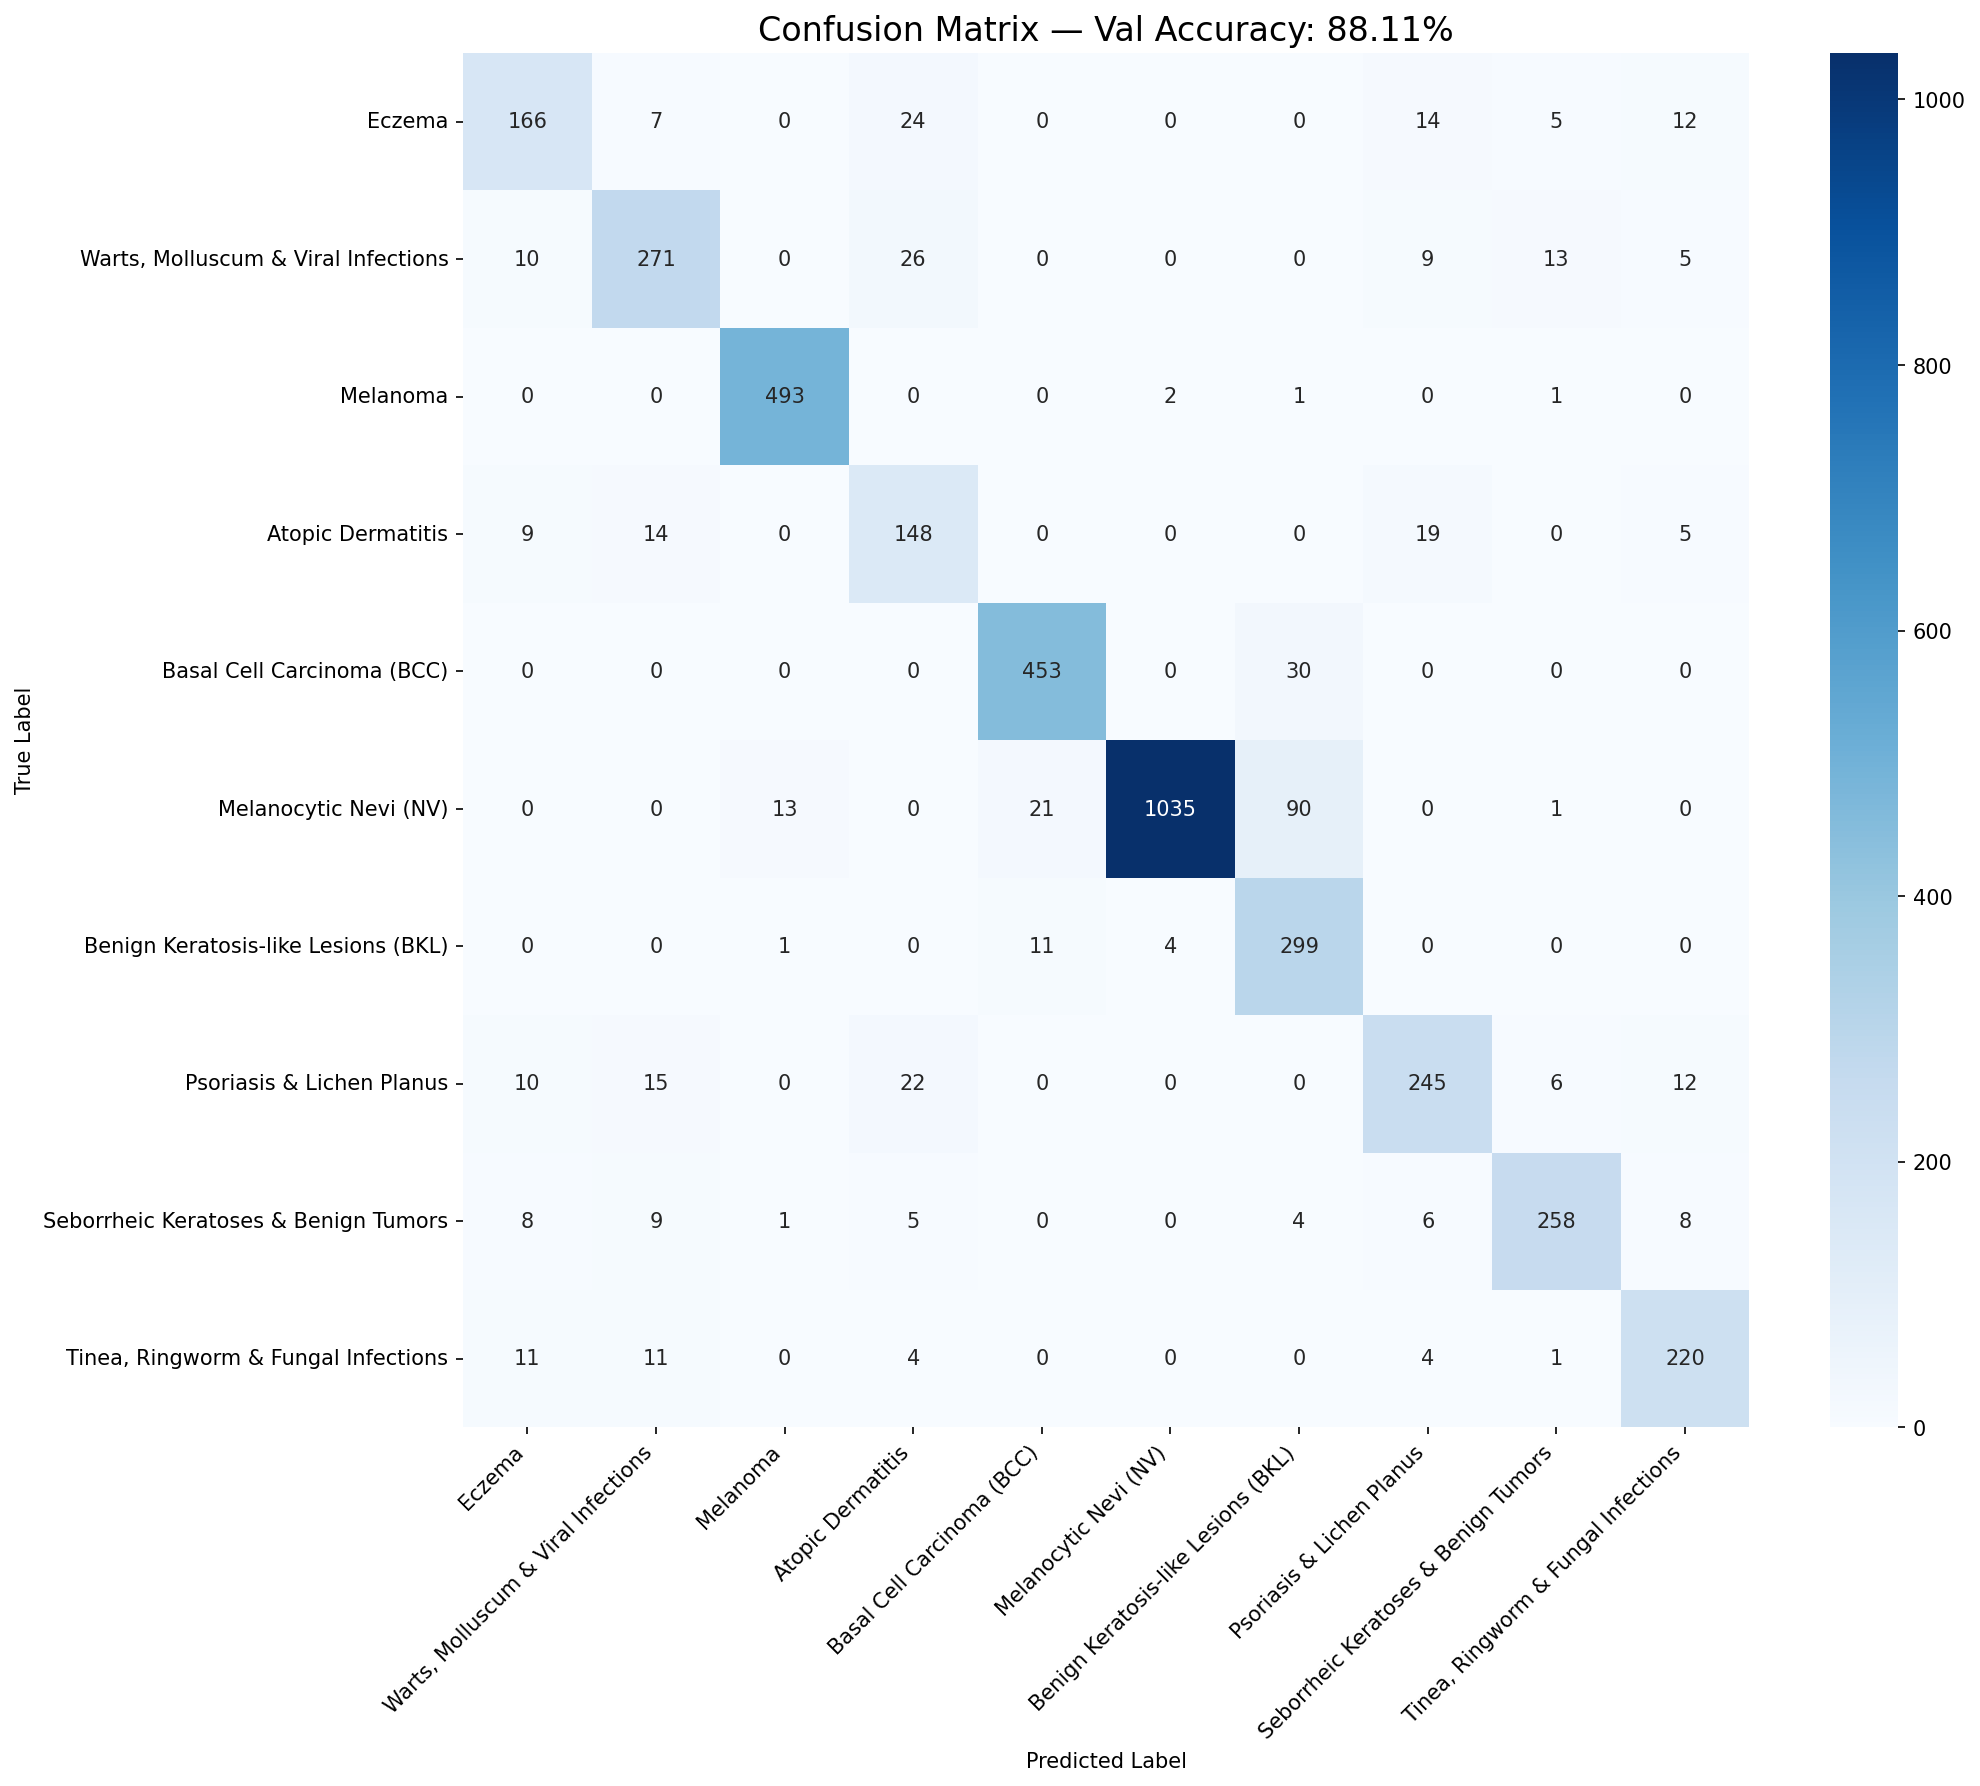

In [4]:
from IPython.display import Image, display
display(Image("/kaggle/working/skin-disease-advisor/models/confusion_matrix.png"))

In [3]:
from kaggle_secrets import UserSecretsClient
import os, sys

os.environ["GEMINI_API_KEY"] = UserSecretsClient().get_secret("GEMINI_API_KEY")
sys.path.insert(0, "/kaggle/working/skin-disease-advisor")
print(" Gemini key loaded")

 Gemini key loaded
